In [2]:
import pandas as pd
import matplotlib.pyplot as plt

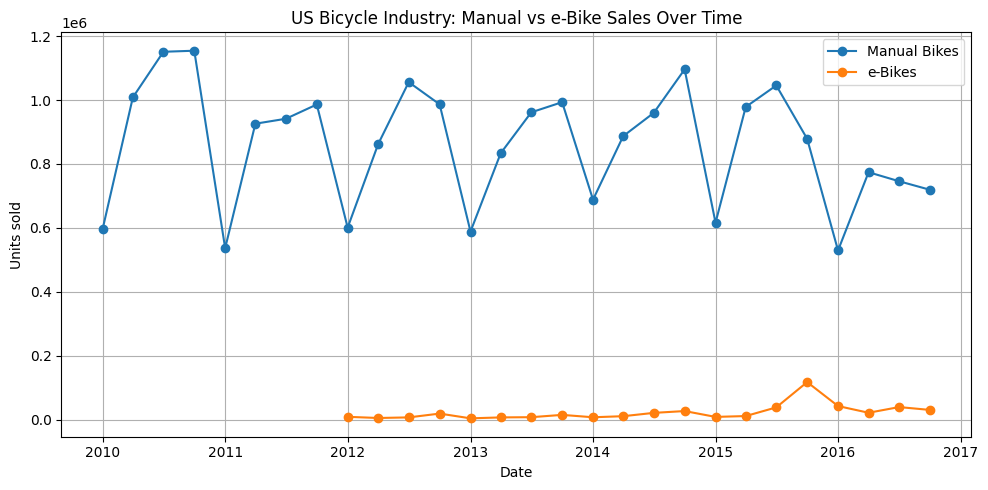

In [4]:
# Charger le fichier CSV
bike = pd.read_csv("Economic value of the bicycle industry US date format - us format.csv", sep=";")

# Convertir la colonne Date
bike["Date"] = pd.to_datetime(bike["Date"])

# Convertir les colonnes numériques
bike["Manual Bikes"] = pd.to_numeric(bike["Manual Bikes"], errors="coerce")
bike["e-Bikes"] = pd.to_numeric(bike["e-Bikes"], errors="coerce")

# Graphique
plt.figure(figsize=(10, 5))
plt.plot(bike["Date"], bike["Manual Bikes"], marker="o", label="Manual Bikes")
plt.plot(bike["Date"], bike["e-Bikes"], marker="o", label="e-Bikes")

plt.title("US Bicycle Industry: Manual vs e-Bike Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Units sold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

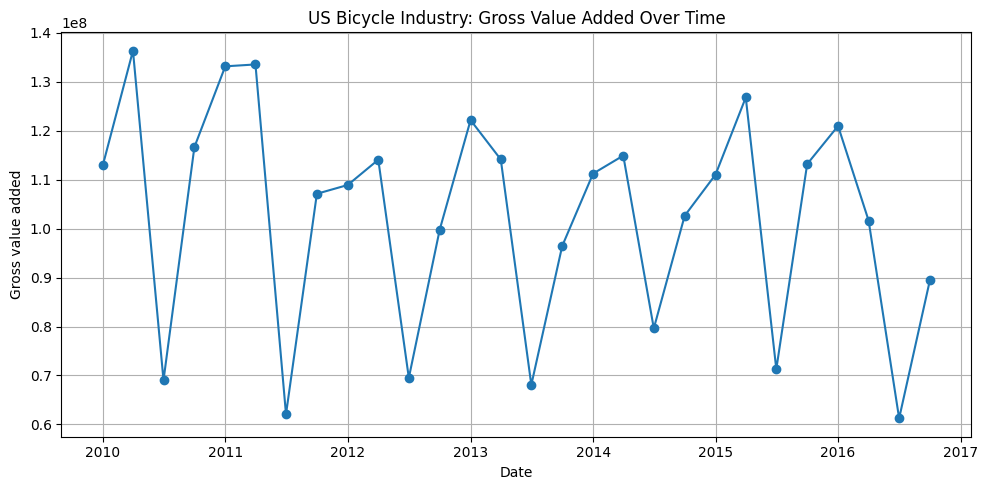

In [5]:
# Charger le fichier CSV
bike = pd.read_csv("Economic value of the bicycle industry US date format - us format.csv", sep=";")

# Convertir la colonne Date
bike["Date"] = pd.to_datetime(bike["Date"])

# Convertir la colonne numérique
bike["Gross Value Added"] = pd.to_numeric(bike["Gross Value Added"], errors="coerce")

# Graphique
plt.figure(figsize=(10, 5))
plt.plot(bike["Date"], bike["Gross Value Added"], marker="o")

plt.title("US Bicycle Industry: Gross Value Added Over Time")
plt.xlabel("Date")
plt.ylabel("Gross value added")
plt.grid(True)
plt.tight_layout()
plt.show()

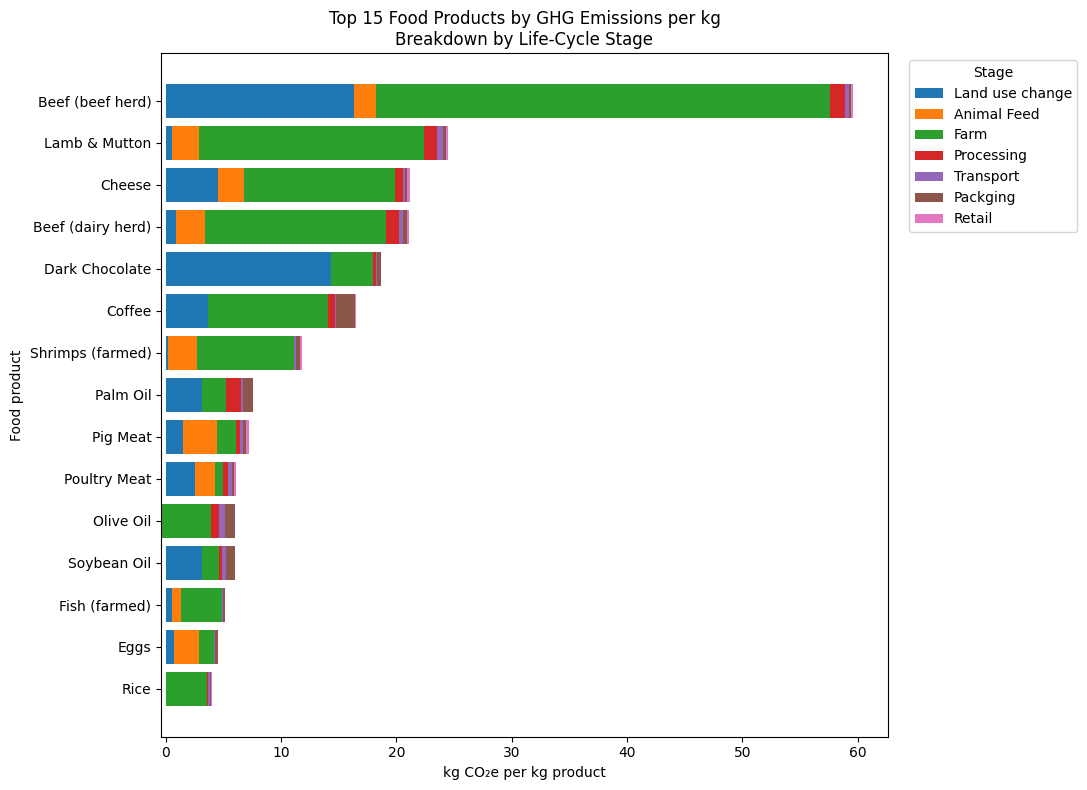

In [ ]:
# Pourcentage des vélos au cours du temps 

# Charger le fichier CSV
ghg = pd.read_csv("GHG-emissions-by-life-cycle-stage-OurWorldinData-upload.csv")

# Supprimer une éventuelle colonne inutile
ghg = ghg.drop(columns=["Unnamed: 8"], errors="ignore")

# Colonnes des étapes du cycle de vie
stage_cols = [
    "Land use change",
    "Animal Feed",
    "Farm",
    "Processing",
    "Transport",
    "Packging",
    "Retail"
]

# Convertir en numérique
for col in stage_cols:
    ghg[col] = pd.to_numeric(ghg[col], errors="coerce")

# Calcul du total
ghg["Total"] = ghg[stage_cols].sum(axis=1)

# Garder les 15 produits les plus polluants
ghg_top = ghg.sort_values("Total", ascending=False).head(15).copy()
ghg_top = ghg_top.sort_values("Total", ascending=True)

# Graphique empilé horizontal
plt.figure(figsize=(11, 8))
left = pd.Series(0, index=ghg_top.index, dtype=float)

for col in stage_cols:
    plt.barh(ghg_top["Food product"], ghg_top[col], left=left, label=col)
    left += ghg_top[col]

plt.title("Top 15 Food Products by GHG Emissions per kg\nBreakdown by Life-Cycle Stage")
plt.xlabel("kg CO₂e per kg product")
plt.ylabel("Food product")
plt.legend(title="Stage", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()